# B — GOP Feature Representation

Reads artifacts from Group B. **Does not recompute GOP.**

| File | Experiment |
| --- | --- |
| `outputs/B/b_predictions.csv` | B1–B4 scalars + `b5_pred` (84-d OLS; no 84-d dump) |
| `outputs/B/b_results.json` | PCC / SCC / MAE / MSE (B1–B5) |
| `outputs/A/a2_results.json` | Group A baseline (if present) |

```text
python scripts/run_experiment.py --config configs/b_gop_representation.yaml
```

Protocol lock: same Kaldi M13 extract, Speechocean762 split, and direct scoring as Group A. Only the GOP representation changes.

On this extract **B1 ≡ B2** (standard GOP is already canonical LPP). B5 is the GOPT-paper 84-d GOP feature (LPP+LPR concat) with train-only OLS — not the full GOPT Transformer.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "outputs" / "B" / "b_results.json").is_file():
    if (ROOT / "GOP-Empirical-Study" / "outputs" / "B" / "b_results.json").is_file():
        ROOT = ROOT / "GOP-Empirical-Study"
    elif (ROOT.parent / "outputs" / "B" / "b_results.json").is_file():
        ROOT = ROOT.parent

OUT = ROOT / "outputs" / "B"
pred = pd.read_csv(OUT / "b_predictions.csv")
results = json.loads((OUT / "b_results.json").read_text(encoding="utf-8"))
protocol = results["protocol"]
cmp = results["comparison"]["test"]
test = pred[pred["split"] == "test"].copy()
print("ROOT", ROOT)
print(
    protocol["acoustic_model"],
    "n_train", protocol["n_train"],
    "n_test", protocol["n_test"],
    "B1≡B2", protocol["b1_identical_to_b2"],
)
table = pd.DataFrame(cmp).T
print(table[["pcc", "scc", "mae", "mse", "n"]].round(4))

a2_path = ROOT / "outputs" / "A" / "a2_results.json"
if a2_path.is_file():
    a2 = json.loads(a2_path.read_text(encoding="utf-8"))["A2"]
    print("A2 test PCC", round(a2["pcc"], 4), "B1 PCC", round(cmp["B1"]["pcc"], 4))

ROOT d:\FSB_MSE\FINAL\GOP-Empirical-Study
kaldi_librispeech_m13 n_train 47076 n_test 47369 B1≡B2 True
       pcc     scc     mae     mse        n
B1  0.3231  0.3128  0.1994  0.1203  47369.0
B2  0.3231  0.3128  0.1994  0.1203  47369.0
B3  0.3277  0.3416  0.1977  0.1207  47369.0
B4  0.3513  0.3418  0.1972  0.1196  47369.0
B5  0.3614  0.3322  0.1971  0.1186  47369.0
A2 test PCC 0.3231 B1 PCC 0.3231


## Test PCC / SCC by representation

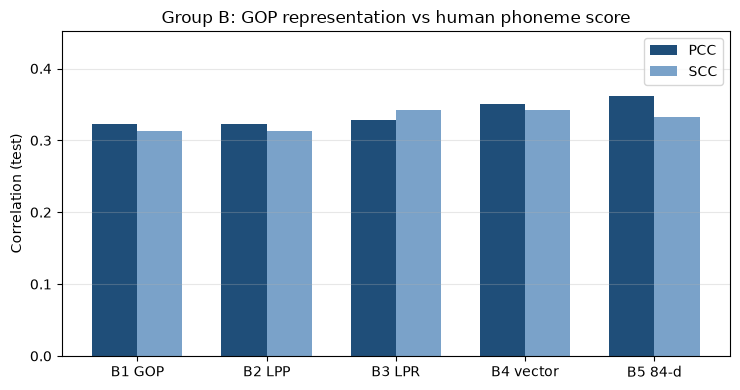

In [2]:
ids = ["B1", "B2", "B3", "B4", "B5"]
labels = ["B1 GOP", "B2 LPP", "B3 LPR", "B4 vector", "B5 84-d"]
pcc = [cmp[i]["pcc"] for i in ids]
scc = [cmp[i]["scc"] for i in ids]
x = range(len(ids))
width = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar([i - width / 2 for i in x], pcc, width, label="PCC", color="#1f4e79")
ax.bar([i + width / 2 for i in x], scc, width, label="SCC", color="#7aa2c9")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("Correlation (test)")
ax.set_title("Group B: GOP representation vs human phoneme score")
ax.set_ylim(0, max(pcc + scc) * 1.25 if max(pcc + scc) > 0 else 1)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "b_comparison_pcc.png", dpi=140)
plt.show()


## Scatter: B3 LPR vs human (test)

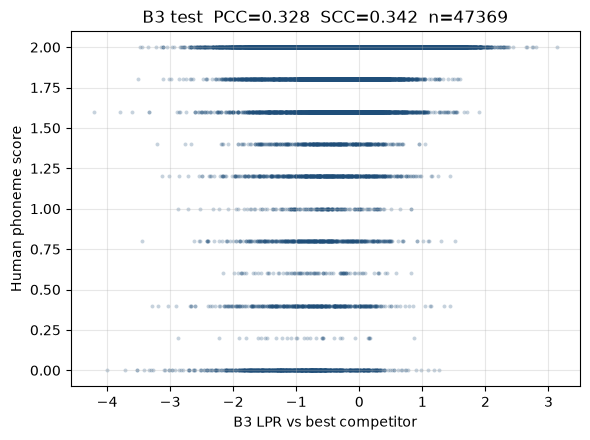

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(test["b3_lpr"], test["human_score"], s=8, alpha=0.25, c="#1f4e79", linewidths=0)
ax.set_xlabel("B3 LPR vs best competitor")
ax.set_ylabel("Human phoneme score")
ax.set_title(
    f"B3 test  PCC={cmp['B3']['pcc']:.3f}  SCC={cmp['B3']['scc']:.3f}  n={len(test)}"
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "b_scatter_b3_lpr_vs_human.png", dpi=140)
plt.show()

## Extreme cases (lowest / highest on test)

Qualitative tails after B1–B5 metrics. **Same test phones, different scores.** Not Group F (no audio / error taxonomy).

| Sort | Column | Why |
| --- | --- | --- |
| B1 / B2 | `b1_gop` | Protocol lock vs A2. On this extract B1 ≡ A1. |
| B3 | `b3_lpr` | Canonical vs best competitor. |
| B4 | `b4_pred` | Train-only OLS on `[LPP, max competitor]`, clip [0, 2]. Do not sort raw `b4_lpp_canonical` (that is B1). |
| B5 | `b5_pred` | Train-only OLS on 84-d LPP+LPR (GOPT-style feature; not full GOPT). |

False-alarm / miss thresholds match A2: human ≥ 1.8 and ≤ 1. The B1 false-alarm table also shows B3/B4 percentile ranks: if `/NG/` stays in the left tail, LPR/vector did not fix that calibration error.


In [4]:
from IPython.display import display
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

m4 = results["B4"]["mapping"]
coef = np.asarray(m4["coef"], dtype=np.float64)
x = test[["b4_lpp_canonical", "b4_lpp_max_competitor"]].to_numpy(dtype=np.float64)
test["b4_pred"] = np.clip(x @ coef + float(m4["intercept"]), 0.0, 2.0)
test["b1_pct"] = test["b1_gop"].rank(pct=True)
test["b3_pct"] = test["b3_lpr"].rank(pct=True)
test["b4_pct"] = test["b4_pred"].rank(pct=True)

id_cols = ["utt_id", "word_id", "phone_id", "phone", "human_score"]
cols = id_cols + ["b1_gop", "b3_lpr", "b4_pred"]
rank_cols = id_cols + ["b1_gop", "b1_pct", "b3_lpr", "b3_pct", "b4_pred", "b4_pct"]
score_round = {"b1_gop": 4, "b3_lpr": 4, "b4_pred": 4, "b1_pct": 3, "b3_pct": 3, "b4_pct": 3}


def show(title, df):
    print(title)
    display(df.round({k: v for k, v in score_round.items() if k in df.columns}))



show("B1 lowest GOP (protocol lock vs A2)", test.nsmallest(10, "b1_gop")[cols])
show("B1 highest GOP", test.nlargest(10, "b1_gop")[cols])
show("B3 lowest LPR", test.nsmallest(10, "b3_lpr")[cols])
show("B3 highest LPR", test.nlargest(10, "b3_lpr")[cols])
show("B4 lowest predicted (train-only OLS, clip [0, 2])", test.nsmallest(10, "b4_pred")[cols])
show("B4 highest predicted", test.nlargest(10, "b4_pred")[cols])

fa = test["human_score"] >= 1.8
miss = test["human_score"] <= 1.0

show(
    "False alarm B1: low GOP, human>=1.8 — ranks under B3/B4",
    test.loc[fa].nsmallest(8, "b1_gop")[rank_cols],
)
show("False alarm B3: low LPR, human>=1.8", test.loc[fa].nsmallest(8, "b3_lpr")[cols])
show("False alarm B4: low pred, human>=1.8", test.loc[fa].nsmallest(8, "b4_pred")[cols])
show("Miss B1: high GOP, human<=1", test.loc[miss].nlargest(8, "b1_gop")[rank_cols])
show("Miss B3: high LPR, human<=1", test.loc[miss].nlargest(8, "b3_lpr")[cols])
show("Miss B4: high pred, human<=1", test.loc[miss].nlargest(8, "b4_pred")[cols])

print("Tail phone counts (n=10)")
for name, col in [("B1 GOP", "b1_gop"), ("B3 LPR", "b3_lpr"), ("B4 pred", "b4_pred")]:
    low = test.nsmallest(10, col)["phone"].value_counts().to_dict()
    high = test.nlargest(10, col)["phone"].value_counts().to_dict()
    print(f"  {name}  lowest {low}  highest {high}")


B1 lowest GOP (protocol lock vs A2)


,utt_id,word_id,phone_id,phone,human_score,b1_gop,b3_lpr,b4_pred
80515,96400013,2,5,NG,0.0,2.8685,-3.9983,0.9883
75531,96080015,5,2,NG,0.0,2.8799,-3.7177,1.0304
80266,96350025,5,4,NG,1.6,2.9101,-3.3427,1.0877
67275,930148,4,2,ZH,1.4,2.9230,-3.2160,1.1073
81121,96470021,2,2,ZH,0.0,2.9949,-3.2791,1.1035
78971,96290015,2,4,NG,2.0,3.0026,-3.4777,1.0750
80545,96400016,2,2,ZH,0.8,3.0376,-3.4515,1.0815
80427,96400007,5,4,NG,0.0,3.1177,-3.3026,1.1095
75382,96080007,4,6,ZH,0.4,3.1510,-3.2810,1.1152
91166,11350345,3,4,NG,1.8,3.1678,-3.1180,1.1404


B1 highest GOP


,utt_id,word_id,phone_id,phone,human_score,b1_gop,b3_lpr,b4_pred
74239,95550134,1,2,N,2.0,9.5676,3.1328,2.0
59251,28920235,6,2,R,2.0,9.1579,1.6323,2.0
58751,27400173,4,2,N,2.0,9.1319,2.7531,2.0
92365,11860361,6,0,L,2.0,9.0973,2.6395,2.0
59538,28970088,2,2,IH,2.0,9.0744,1.5816,2.0
93349,12930028,5,5,N,2.0,9.0586,2.6624,2.0
75024,96010010,6,5,L,2.0,9.0531,2.7466,2.0
49426,14200353,8,2,M,2.0,8.9985,1.7665,2.0
71221,85810152,3,2,N,2.0,8.9985,2.2382,2.0
89306,10610129,3,2,L,2.0,8.9851,2.3133,2.0


B3 lowest LPR


...

Miss B3: high LPR, human<=1


,utt_id,word_id,phone_id,phone,human_score,b1_gop,b3_lpr,b4_pred
80676,96400024,4,3,P,0.8,7.5528,1.5238,2.0
74986,96010009,4,4,N,0.4,7.7258,1.4411,2.0
49623,14220081,2,0,L,0.4,7.4760,1.3361,2.0
92417,11860373,1,5,K,0.8,7.7986,1.2902,2.0
49695,14220140,5,3,D,0.0,7.5505,1.2579,2.0
49647,14220102,0,2,N,0.0,7.2918,1.1893,2.0
75378,96080007,4,2,N,0.4,7.2786,1.1431,2.0
74984,96010009,4,2,L,0.4,7.2896,1.1152,2.0


Miss B4: high pred, human<=1


,utt_id,word_id,phone_id,phone,human_score,b1_gop,b3_lpr,b4_pred
49347,14200296,3,0,AH,1.0,7.6941,0.6444,2.0
49623,14220081,2,0,L,0.4,7.4760,1.3361,2.0
49647,14220102,0,2,N,0.0,7.2918,1.1893,2.0
49695,14220140,5,3,D,0.0,7.5505,1.2579,2.0
63939,50170131,4,1,T,0.8,7.2721,0.6918,2.0
74923,96010006,5,1,T,0.8,7.1165,0.9178,2.0
74984,96010009,4,2,L,0.4,7.2896,1.1152,2.0
74986,96010009,4,4,N,0.4,7.7258,1.4411,2.0


Tail phone counts (n=10)
  B1 GOP  lowest {'NG': 6, 'ZH': 4}  highest {'N': 4, 'L': 3, 'R': 1, 'IH': 1, 'M': 1}
  B3 LPR  lowest {'NG': 6, 'ZH': 2, 'DH': 1, 'F': 1}  highest {'N': 5, 'L': 3, 'M': 2}
  B4 pred  lowest {'NG': 6, 'ZH': 3, 'DH': 1}  highest {'IH': 2, 'F': 2, 'N': 2, 'G': 1, 'S': 1, 'V': 1, 'T': 1}
